<div style="
    background: linear-gradient(90deg, #8e0e92, #c31492);
    padding: 20px;
    border-radius: 40px;
    text-align: center;
    color: white;
    font-size: 32px;
    font-weight: bold;
    font-family: Arial;
    width: 90%;
    margin: auto;
">
    Movie Review Sentiment Analysis Using LSTM
</div>

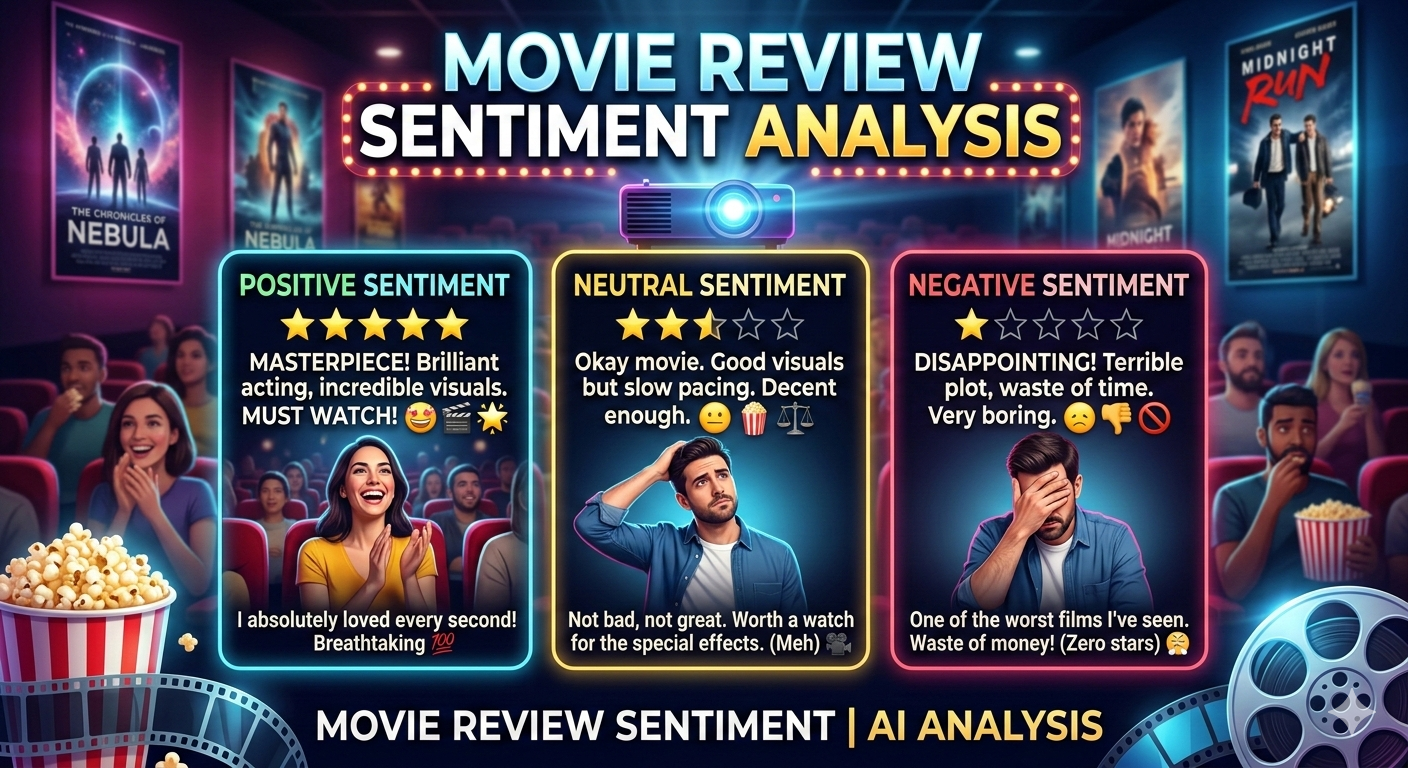

<div style="
    background: linear-gradient(180deg,#f3e8ff,#faf5ff);
    color:#2d2d2d;
    padding:25px;
    border-radius:15px;
    font-family: Arial, sans-serif;
    line-height:1.7;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
🌸 About Author
</h2>

<p style="text-align:center; font-size:16px;">
<strong>Project:</strong> Movie Review Sentiment Analysis
</p>

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
📌 Introduction
</h2>

👋 Hello everyone! My name is <strong>Muqadas Ejaz</strong>. I am a Junior AI Engineer passionate about using data and artificial intelligence to solve real-world problems. I actively explore machine learning, deep learning, and computer vision, and I share my projects and learning journey on Kaggle.

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
🔎 About Me
</h2>

As a Junior AI Engineer, I work on designing, training, and deploying AI models. My focus includes data analysis, machine learning pipelines, and building intelligent systems that generate meaningful insights. My journey is driven by curiosity and continuous learning.

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
🚀 My Work
</h2>

I regularly upload data analysis notebooks and AI projects on Kaggle, showcasing skills in:

<ul>
<li>Data Manipulation</li>
<li>Exploratory Data Analysis (EDA)</li>
<li>Machine Learning</li>
<li>Deep Learning</li>
<li>Computer Vision</li>
</ul>

Through these notebooks, I aim to contribute to the AI community by sharing methodologies, practical implementations, and insights.

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
💡 Passion & Goals
</h2>

My passion for AI motivates me to continuously learn, experiment, and build impactful solutions. I strive to expand my expertise and contribute to meaningful advancements in AI technologies.

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
🤝 Let's Connect
</h2>

I am always open to collaboration, knowledge sharing, and networking opportunities.

<p>
<strong>Contact Info:</strong><br>
📧 Email: muqadasejaz3@gmail.com<br>
🔗 <a href="https://www.linkedin.com/in/muqadasejaz/" target="_blank">LinkedIn</a><br>
🐦 <a href="https://x.com/muqadas__ejaz" target="_blank">Twitter</a><br>
💻 <a href="https://github.com/muqadasejaz" target="_blank">Github</a>
</p>

<hr style="border:1px solid #e9d5ff;">

<h2 style="color:#8b5cf6; text-align:center; font-weight:700;">
📊 About Dataset
</h2>

<ul>
<li><strong>Dataset:</strong> 
<a href="https://www.kaggle.com/datasets/karimabdulnabi/fruit-classification10-class/data" target="_blank">
Movie Reviews Dataset
</a></li>
<li><strong>Model Used:</strong> LSTM, BiLSTM</li>
</ul>

</div>

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Import Libraries</strong>
</h1>

In [126]:
# ==============================
# Import Required Libraries
# ==============================

# ------------------------------
# Data Manipulation & Numerical Operations
# ------------------------------
import pandas as pd          # Data handling and dataframe operations
import numpy as np           # Numerical computations and array processing

# ------------------------------
# Data Visualization
# ------------------------------
import matplotlib.pyplot as plt   # Basic plotting and visualization
import seaborn as sns             # Advanced statistical visualizations

# ------------------------------
# Text Processing & Cleaning
# ------------------------------
import re                          # Regular expressions for text cleaning
import string                      # String operations (punctuation removal)

# ------------------------------
# Natural Language Processing (NLP)
# ------------------------------
from textblob import TextBlob     # Text processing and sentiment utilities
import nltk                        # NLP toolkit for tokenization and preprocessing
from nltk.corpus import stopwords  # Stopword removal
from nltk.stem import WordNetLemmatizer  # Word normalization (lemmatization)
import emoji                       # Emoji detection and processing

# Download required NLTK resources
nltk.download('punkt')
nltk.download('wordnet')

# ------------------------------
# Text Tokenization & Sequence Processing
# ------------------------------
from tensorflow.keras.preprocessing.text import Tokenizer   # Convert text to tokens
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Pad sequences to equal length
from keras.preprocessing import sequence

# ------------------------------
# Deep Learning Model (LSTM)
# ------------------------------
from tensorflow.keras.models import Sequential   # Sequential neural network model
from tensorflow.keras.layers import *            # Core neural network layers
from keras.layers import LSTM, Dense, SimpleRNN, Embedding, Flatten, Dropout
from keras.activations import softmax            # Softmax activation for classification

# ------------------------------
# Model Training & Evaluation
# ------------------------------
from sklearn.model_selection import train_test_split   # Split dataset into train/test sets

# ------------------------------
# Utility
# ------------------------------
import warnings
warnings.filterwarnings('ignore')   # Suppress warning messages

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Read Dataset</strong>
</h1>

In [127]:
# ============================================
# Load Dataset
# ============================================

# Read the IMDB movie reviews dataset from Kaggle input directory
df = pd.read_csv('/kaggle/input/datasets/mahmoudshaheen1134/imdp-data/IMDB Dataset.csv')

# Display first 5 rows of dataset
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>DataSet Overview</strong>
</h1>

In [128]:
# ============================================
# Dataset Overview
# ============================================

# Print overall shape of dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Print number of rows and columns separately
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Shape: (50000, 2)
Number of Rows: 50000
Number of Columns: 2


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Check Duplicates</strong>
</h1>

In [129]:
# ============================================
# Handling Duplicate Records
# ============================================

# Check total number of duplicate rows
print("Duplicates in Dataset:", df.duplicated().sum())

# Remove duplicate rows (if any)
df.drop_duplicates(inplace=True)

# Verify duplicates after removal
print("Duplicates after Preprocessing:", df.duplicated().sum())


Duplicates in Dataset: 418
Duplicates after Preprocessing: 0


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Converting Target Variable to Numeric</strong>
</h1>

In [130]:
df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [131]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class distribution:", class_distribution)

Class distribution: {np.int64(0): np.int64(19758), np.int64(1): np.int64(19907)}


In [132]:
import numpy as np

# If y_train shape is (num_samples, 1) or one-hot, flatten it
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Text Preprocessing</strong>
</h1>

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>LowerCasing Text</strong>
</h1>

In [133]:
# Convert all reviews to lowercase for normalization
df['review'] = df['review'].str.lower()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. <br /><br />the...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Remove HTML Tags</strong>
</h1>

In [134]:
# ============================================
# Remove HTML Tags from Reviews
# ============================================

from bs4 import BeautifulSoup   # Library for parsing HTML and XML content

def remove_html_tags(text):
    """
    This function removes HTML tags from a given text string.
    It uses BeautifulSoup to parse the HTML structure
    and extract only the clean textual content.
    """
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text()

# Apply HTML tag removal function to the 'review' column
df['review'] = df['review'].apply(remove_html_tags)
# Display updated dataset
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Remove URLs</strong>
</h1>

In [135]:
# --------------------------------------------
# Remove URLs from text using Regular Expression
# --------------------------------------------

def remove_urls(text):
    """
    Removes URLs starting with http or www from text.
    """
    return re.sub(r'http\S+|www\S+', '', text)

# Apply URL removal function to 'review' column
df['review'] = df['review'].apply(remove_urls)


# Display updated dataset
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Handling Emojies</strong>
</h1>

In [136]:
# ============================================
# Convert Emojis to Text
# ============================================

def convert_emojis(text):
    """
    Converts emojis into descriptive text.
    Example: 😊 -> smiling_face
    """
    return emoji.demojize(text)

# Apply emoji conversion
df['review'] = df['review'].apply(convert_emojis)

# Display updated dataset
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Handling ChatWords</strong>
</h1>

In [137]:
# Define a dictionary of chat word mappings
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [138]:
# ============================================
# Replace Chat Words with Full Forms
# ============================================

# Convert dictionary keys to lowercase for proper matching
chat_words_lower = {key.lower(): value.lower() for key, value in chat_words.items()}

def replace_chat_words(text):
    """
    Replaces chat abbreviations (e.g., LOL, BRB)
    with their expanded full meanings.
    """
    words = text.split()
    
    for i, word in enumerate(words):
        if word in chat_words_lower:
            words[i] = chat_words_lower[word]
    
    return ' '.join(words)

# Apply function to 'review' column
df['review'] = df['review'].apply(replace_chat_words)

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Remove Punctuation</strong>
</h1>

In [139]:
# ============================================
# Remove Punctuation from Text
# ============================================

def remove_punctuation(text):
    """
    Removes punctuation marks from a given text string.
    Keeps only alphanumeric characters and spaces.
    """
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply punctuation removal to 'review' column
df['review'] = df['review'].apply(remove_punctuation)

# Display updated dataset
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend te...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the tears in my eyes of...,1


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Handling StopWords</strong>
</h1>

In [140]:
# ============================================
# Handling StopWords
# ============================================

# Download NLTK stopwords corpus
nltk.download('stopwords')

# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Function to remove stop words from text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply remove_stopwords function to 'Text' column
df['review'] = df['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Lemmatization</strong>
</h1>

In [141]:
# ============================================
# Text Lemmatization
# ============================================

# Initialize WordNet Lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """
    Applies verb-based lemmatization to each word.
    Converts words to their base form.
    Example: 'running' -> 'run'
    """
    return ' '.join([
        wordnet_lemmatizer.lemmatize(word, pos='v') 
        for word in text.split()
    ])

# Apply lemmatization to 'review' column
df['review_lemmatized'] = df['review'].apply(lemmatize_text)

# Display updated dataset
df.head()

,review,sentiment,review_lemmatized
0,one reviewers mentioned watching 1 oz episode ...,1,one reviewers mention watch 1 oz episode youll...
1,wonderful little production filming technique ...,1,wonderful little production film technique una...
2,thought wonderful way spend tears eyes hot sum...,1,think wonderful way spend tear eye hot summer ...
3,basically theres family little boy jake thinks...,0,basically theres family little boy jake think ...
4,petter matteis love tears eyes money visually ...,1,petter matteis love tear eye money visually st...


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Train Test Split</strong>
</h1>

In [142]:
# ============================================
# Train-Test Split
# ============================================

# Define input (X) and target (y)
X = df['review_lemmatized']   # Processed text
y = df['sentiment']           # Target labels

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # For reproducibility
    stratify=y          # Preserve class distribution
)

# Display split sizes
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

Training Set Size: 39665
Testing Set Size: 9917


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Tokenization and Padding Sequences</strong>
</h1>

In [143]:
# ============================================
# Tokenization
# ============================================

# Initialize tokenizer
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
# num_words → keeps top 5000 most frequent words
# oov_token → handles unseen words

# Fit tokenizer on training data only
tokenizer.fit_on_texts(X_train)

# Convert text into sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 180777


In [144]:
# ============================================
# Padding Sequences
# ============================================

max_length = 200   # You can tune this value

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training Shape:", X_train_pad.shape)
print("Testing Shape:", X_test_pad.shape)

Training Shape: (39665, 200)
Testing Shape: (9917, 200)


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Model Building - LSTM</strong>
</h1>

In [145]:
# ============================================
# Define LSTM Model
# ============================================

from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dropout, Dense

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(64))

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Compile Model</strong>
</h1>

In [146]:
# ============================================
# Compile Model
# ============================================

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Model Training</strong>
</h1>

In [147]:
# ============================================
# Train Model
# ============================================

from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5104 - loss: 0.6932 - val_accuracy: 0.5033 - val_loss: 0.6927
Epoch 2/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.5190 - loss: 0.6888 - val_accuracy: 0.5273 - val_loss: 0.6832
Epoch 3/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.5496 - loss: 0.6749 - val_accuracy: 0.6705 - val_loss: 0.6051
Epoch 4/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6754 - loss: 0.6024 - val_accuracy: 0.8388 - val_loss: 0.3902
Epoch 5/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8632 - loss: 0.3346 - val_accuracy: 0.8680 - val_loss: 0.3374
Epoch 6/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9027 - loss: 0.2497 - val_accuracy: 0.8743 - val_loss: 0.3092
Epoch 7/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9227 - loss: 0.2092 - val_accuracy: 0.8748 - val_loss: 0.3166
Epoch 8/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9372 - loss: 0.1789 - 

In [148]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8814 - loss: 0.2908
Test Accuracy: 87.73%


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Plotting Training and Validation Accuracy & Loss</strong>
</h1>

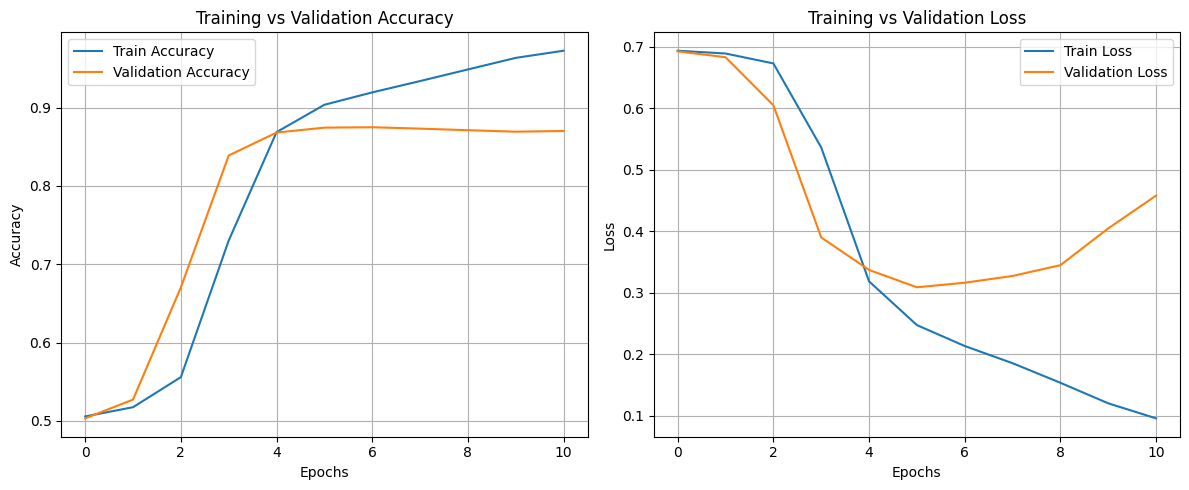

In [149]:
# ============================================
# Plot Training vs Validation Accuracy and Loss
# ============================================

import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Predictions</strong>
</h1>

In [154]:
# ============================================
# Generate Predictions
# ============================================

import numpy as np


preds = model.predict(X_test_pad)
pred_labels = (preds > 0.5).astype(int)


310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Confusion Matrix</strong>
</h1>

In [157]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# 2. Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# 3. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Optional: classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Confusion Matrix:
[[4159  781]
 [ 436 4541]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      4940
           1       0.85      0.91      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


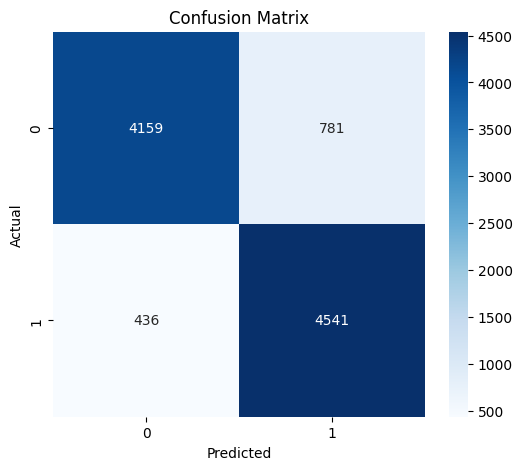

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict and convert to binary labels
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Model Building - bidirectional LSTM</strong>
</h1>

In [161]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense

# New model name
model_bi = Sequential()

# Embedding layer
model_bi.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

# First LSTM layer (unchanged)
model_bi.add(LSTM(128, return_sequences=True))
model_bi.add(Dropout(0.3))

# Second LSTM layer → make it bidirectional
model_bi.add(Bidirectional(LSTM(64)))
model_bi.add(Dropout(0.3))  # optional

# Dense layers
model_bi.add(Dense(64, activation='relu'))
model_bi.add(Dense(1, activation='sigmoid'))

# Compile
model_bi.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Model Training</strong>
</h1>

In [163]:
# Train
history_bi = model_bi.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7395 - loss: 0.5124 - val_accuracy: 0.8223 - val_loss: 0.3910
Epoch 2/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8883 - loss: 0.2846 - val_accuracy: 0.8729 - val_loss: 0.2985
Epoch 3/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9076 - loss: 0.2419 - val_accuracy: 0.8786 - val_loss: 0.3002
Epoch 4/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9239 - loss: 0.2030 - val_accuracy: 0.8786 - val_loss: 0.3375
Epoch 5/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9303 - loss: 0.1919 - val_accuracy: 0.8702 - val_loss: 0.3292
Epoch 6/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9459 - loss: 0.1535 - val_accuracy: 0.8739 - val_loss: 0.3692
Epoch 7/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9561 - loss: 0.1294 - val_accuracy: 0.8728 - val_loss: 0.3842
Epoch 8/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9659 - loss: 0.1028 - 

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Plotting Training and Validation Accuracy & Loss </strong>
</h1>

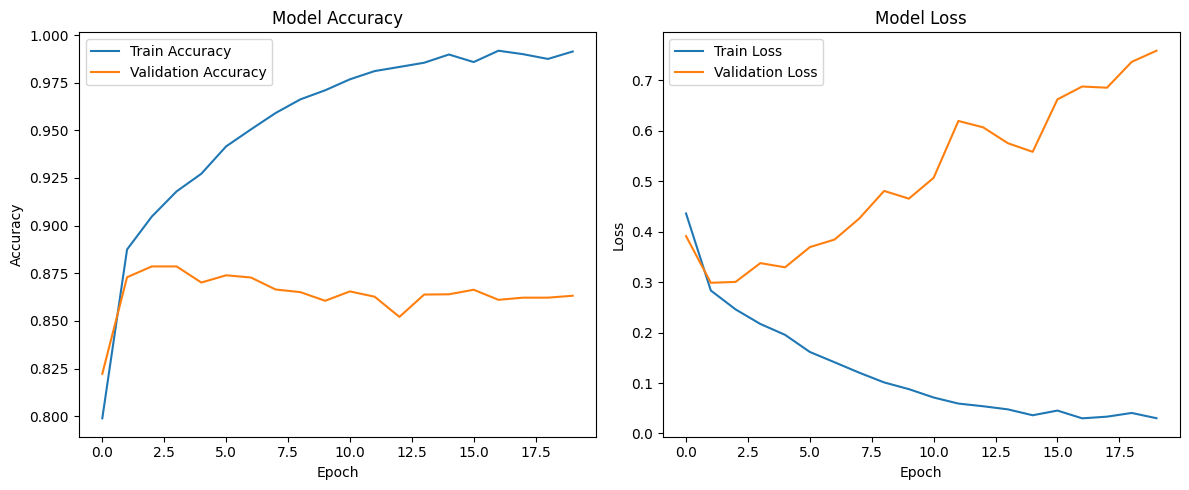

In [164]:
# ============================================
# Plot Training vs Validation Accuracy and Loss
# ============================================

import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_bi.history['accuracy'], label='Train Accuracy')
plt.plot(history_bi.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_bi.history['loss'], label='Train Loss')
plt.plot(history_bi.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

<h1 style="
    text-align:center;
    color:#b04acb;
    font-family: Georgia, serif;
    font-weight: 800;
    letter-spacing: 0.5px;
    margin-top: 40px;
">
    <strong>Confusion Matrix - bidirectional LSTM</strong>
</h1>

310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Confusion Matrix:
[[4282  658]
 [ 687 4290]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4940
           1       0.87      0.86      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



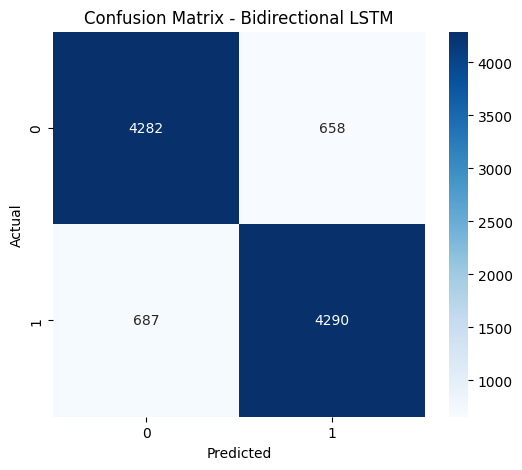

In [165]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Predict probabilities on test set
y_pred_probs = model_bi.predict(X_test_pad)

# 2. Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Optional: classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Plot confusion matrix as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bidirectional LSTM')
plt.show()